In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")
import plotnine as p9
import io
import requests
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import probplot
from statsmodels.stats.outliers_influence import variance_inflation_factor
plt.style.use('seaborn-v0_8')

# display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:
health = pd.read_csv('gender_health.csv')
greenspace = pd.read_csv('green_blue.csv')
imd = pd.read_csv('area_wealth.csv')
rurban = pd.read_csv('rural_urban_classification.csv')
life_exp = pd.read_csv('healthylifeexpectancyuk_V2.csv')

In [3]:
rurban.head()

,FID,LAD21CD,LAD21NM,LAD21NMW,BNG_E,BNG_N,LONG,LAT,GlobalID,LAD21CD_1,LAD21NM_1,RUC21CD,RUC21NM,Urban_rura,Shape_Leng,Shape__Area,Shape__Length,GlobalID_2
0,1,E06000001,Hartlepool,,447160,531474,-1.27,54.68,353a47f9-0a38-42b9-92d5-612794437e27,E06000001,Hartlepool,UUN,Urban: Majority nearer to a major town or city,Urban,66110.01,98351072.84,66110.01,5d65a474-40ea-48a5-b647-e49b6c7f1f15
1,2,E06000002,Middlesbrough,,451141,516887,-1.21,54.54,b4dcd1ed-2166-47e9-ae61-4bbe05c4b0a9,E06000002,Middlesbrough,UUN,Urban: Majority nearer to a major town or city,Urban,41055.79,54553586.46,41055.79,b514dfaa-6d49-4959-819a-6c6a00def2f9
2,3,E06000003,Redcar and Cleveland,,464361,519597,-1.01,54.57,9c578b25-3bf9-423f-aa91-ce5315a2b54f,E06000003,Redcar and Cleveland,UIN,Intermediate urban: Majority nearer to a major...,Urban,105292.10,253785360.20,105292.10,7a326cdc-9115-4e65-94f0-4d63e65f9f90
3,4,E06000004,Stockton-on-Tees,,444940,518183,-1.31,54.56,b3a6ee7f-7e10-4ebf-8e60-c265f439855d,E06000004,Stockton-on-Tees,UUN,Urban: Majority nearer to a major town or city,Urban,108085.19,209730808.80,108085.19,33914785-fd8b-4fba-876b-729386d0cd14
4,5,E06000005,Darlington,,428029,515648,-1.57,54.54,933c21a1-e315-44ab-8471-caa069f09686,E06000005,Darlington,UUN,Urban: Majority nearer to a major town or city,Urban,107203.15,197477768.13,107203.15,2207122a-b50d-485c-bade-0843c25cd9f0


In [4]:
health.head()

,Year,Local Authority,Area Code,Health Status,Sex,Count,Population,Age-standardised Percentage,Lower 95% Confidence Interval,Upper 95% Confidence Interval,Notes
0,2021,Adur,E07000223,Very good,Female,"14,710","33,330",46.80,46.00,47.50,[z]
1,2021,Adur,E07000223,Very good,Male,"14,565","31,220",47.20,46.40,48.00,[z]
2,2021,Adur,E07000223,Very good,Persons,"29,265","64,545",47.00,46.40,47.50,[z]
3,2021,Adur,E07000223,Good,Female,"11,645","33,330",34.60,34.00,35.30,[z]
4,2021,Adur,E07000223,Good,Male,"10,930","31,220",35.10,34.40,35.70,[z]


In [5]:
greenspace.head()

,FID,MSOA_Km2,MSOA_Code,MSOA_Name,MSOA_Ha,AreaName,LA_Code20,LA_Name20,Reg_Code,Reg_Name,All_Ages,GB_Sp_Ha,GB_Sp_Perc,GB_Sp_1000,NoProwData
0,1,0.63,E02000416,Haringey 020,62.85,Hornsey East,E09000014,Haringey,E12000007,LONDON,8134,2.29,3.65,0.28,No Public Rights of Way dataset available for ...
1,2,1.06,E02000417,Haringey 021,105.95,Muswell Hill South,E09000014,Haringey,E12000007,LONDON,6569,28.57,26.96,4.35,No Public Rights of Way dataset available for ...
2,3,0.71,E02000418,Haringey 022,71.34,Hornsey West,E09000014,Haringey,E12000007,LONDON,5341,11.95,16.75,2.24,No Public Rights of Way dataset available for ...
3,4,0.64,E02000419,Haringey 023,64.24,Harringay Ladder North,E09000014,Haringey,E12000007,LONDON,8974,4.19,6.53,0.47,No Public Rights of Way dataset available for ...
4,5,0.58,E02000420,Haringey 024,57.73,Tottenham Green West,E09000014,Haringey,E12000007,LONDON,8251,0.74,1.28,0.09,No Public Rights of Way dataset available for ...


In [6]:
imd.head()

,LSOA code (2011),LSOA name (2011),Local Authority District code (2019),Local Authority District name (2019),Index of Multiple Deprivation (IMD) Score,Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived),Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)
0,E01000001,City of London 001A,E09000001,City of London,6.21,29199,9
1,E01000002,City of London 001B,E09000001,City of London,5.14,30379,10
2,E01000003,City of London 001C,E09000001,City of London,19.40,14915,5
3,E01000005,City of London 001E,E09000001,City of London,28.65,8678,3
4,E01000006,Barking and Dagenham 016A,E09000002,Barking and Dagenham,19.84,14486,5


In [7]:
# Create new health df and remove unnecessary columns
health_2 = health.drop(columns=['Count', 'Population', 'Lower 95% Confidence Interval', 'Upper 95% Confidence Interval', 'Notes'])

#rename existing columns
health_2 = health_2.rename(columns={
    'Area Code': 'area_code',
    'Local Authority': 'la_name',
    'Health Status': 'health_status',
    'Sex': 'sex',
    'Age-standardised Percentage': 'age_std_perc'
})

health_2

,Year,la_name,area_code,health_status,sex,age_std_perc
0,2021,Adur,E07000223,Very good,Female,46.80
1,2021,Adur,E07000223,Very good,Male,47.20
2,2021,Adur,E07000223,Very good,Persons,47.00
3,2021,Adur,E07000223,Good,Female,34.60
4,2021,Adur,E07000223,Good,Male,35.10
...,...,...,...,...,...,...
4930,2021,York,E06000014,Bad,Male,3.20
4931,2021,York,E06000014,Bad,Persons,3.40
4932,2021,York,E06000014,Very bad,Female,0.90
4933,2021,York,E06000014,Very bad,Male,0.90


In [8]:
# Remove welsh LA's as other data only has England LA's
health_2 = health_2[health_2['area_code'].str.startswith('E')].copy()
health_2

,Year,la_name,area_code,health_status,sex,age_std_perc
0,2021,Adur,E07000223,Very good,Female,46.80
1,2021,Adur,E07000223,Very good,Male,47.20
2,2021,Adur,E07000223,Very good,Persons,47.00
3,2021,Adur,E07000223,Good,Female,34.60
4,2021,Adur,E07000223,Good,Male,35.10
...,...,...,...,...,...,...
4930,2021,York,E06000014,Bad,Male,3.20
4931,2021,York,E06000014,Bad,Persons,3.40
4932,2021,York,E06000014,Very bad,Female,0.90
4933,2021,York,E06000014,Very bad,Male,0.90


In [9]:
# calculate weighted health scores for each sex
weights = {
    'Very good': 5,
    'Good': 4,
    'Fair': 3,
    'Bad': 2,
    'Very bad': 1
}
#Map the weights and add a new column with the weighted calculations
health_2['weights'] = health_2['health_status'].map(weights)
health_2['weighted_score'] = (health_2['age_std_perc'] * health_2['weights']) / 100

health_2

,Year,la_name,area_code,health_status,sex,age_std_perc,weights,weighted_score
0,2021,Adur,E07000223,Very good,Female,46.80,5,2.34
1,2021,Adur,E07000223,Very good,Male,47.20,5,2.36
2,2021,Adur,E07000223,Very good,Persons,47.00,5,2.35
3,2021,Adur,E07000223,Good,Female,34.60,4,1.38
4,2021,Adur,E07000223,Good,Male,35.10,4,1.40
...,...,...,...,...,...,...,...,...
4930,2021,York,E06000014,Bad,Male,3.20,2,0.06
4931,2021,York,E06000014,Bad,Persons,3.40,2,0.07
4932,2021,York,E06000014,Very bad,Female,0.90,1,0.01
4933,2021,York,E06000014,Very bad,Male,0.90,1,0.01


In [10]:
# sum up the weighted scores to have one combined score per sex for each LA
health_scores = health_2.groupby(['area_code', 'la_name', 'sex'])['weighted_score'].sum().reset_index()

# create pivot to combine area code/names into 1 row each, with columns for each status and sex combo weighted scores
health_scores = health_scores.pivot_table(
    index = ['area_code', 'la_name'],
    columns = 'sex',
    values = 'weighted_score'
).reset_index()

# rename the weighted score columns
health_scores.columns = ['area_code', 'la_name', 'female_hs', 'male_hs', 'all_hs']

health_scores

,area_code,la_name,female_hs,male_hs,all_hs
0,E06000001,Hartlepool,4.08,4.11,4.09
1,E06000002,Middlesbrough,4.09,4.13,4.11
2,E06000003,Redcar and Cleveland,4.12,4.14,4.14
3,E06000004,Stockton-on-Tees,4.16,4.18,4.17
4,E06000005,Darlington,4.18,4.19,4.19
...,...,...,...,...,...
302,E09000028,Southwark,4.20,4.25,4.22
303,E09000029,Sutton,4.26,4.28,4.28
304,E09000030,Tower Hamlets,4.00,4.10,4.05
305,E09000031,Waltham Forest,4.16,4.21,4.18


In [11]:
# create pivot to combine area code/names into 1 row each, with columns for each status and sex combo percentage value
health_perc = health_2.pivot_table(
    index = ['area_code', 'la_name'],
    columns = ['health_status', 'sex'],
    values = 'age_std_perc'
).reset_index()

# flatten the pivot into columns and rename them
health_perc.columns = [
    f'{health_s}_{sex}'.lower()
    .replace('very good', 'v_gd')
    .replace('very bad', 'v_bd')
    .replace(' ', '_')
    .replace('persons', 'all')
    if health_s else sex
    for health_s, sex in health_perc.columns
]

health_perc

,area_code_,la_name_,bad_female,bad_male,bad_all,fair_female,fair_male,fair_all,good_female,good_male,good_all,v_bd_female,v_bd_male,v_bd_all,v_gd_female,v_gd_male,v_gd_all
0,E06000001,Hartlepool,6.20,5.80,6.00,15.90,15.30,15.60,33.70,33.70,33.70,1.90,1.90,1.90,42.30,43.40,42.80
1,E06000002,Middlesbrough,6.50,5.60,6.10,15.10,14.80,14.90,33.40,33.20,33.30,2.00,1.90,2.00,43.00,44.50,43.80
2,E06000003,Redcar and Cleveland,5.70,5.20,5.40,14.90,14.70,14.90,34.20,33.70,34.00,1.70,1.70,1.70,43.50,44.70,44.10
3,E06000004,Stockton-on-Tees,5.10,4.50,4.90,14.20,14.10,14.20,33.80,33.70,33.70,1.40,1.60,1.50,45.40,46.10,45.70
4,E06000005,Darlington,4.70,4.30,4.50,14.00,14.10,14.00,35.00,34.50,34.80,1.20,1.20,1.20,45.10,45.80,45.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
302,E09000028,Southwark,5.00,4.30,4.60,13.60,12.90,13.30,31.30,30.90,31.10,1.70,1.40,1.60,48.40,50.50,49.40
303,E09000029,Sutton,3.60,3.10,3.40,11.80,11.70,11.80,35.20,34.70,35.00,1.00,1.00,1.00,48.40,49.40,48.90
304,E09000030,Tower Hamlets,7.80,6.20,7.00,16.90,15.00,15.90,31.40,32.60,32.00,2.80,2.30,2.50,41.10,43.90,42.60
305,E09000031,Waltham Forest,4.90,4.20,4.60,14.10,13.30,13.70,34.40,34.20,34.30,1.60,1.30,1.50,45.00,46.90,45.90


In [12]:
health_perc = health_perc.rename(columns={
    'area_code_': 'area_code',
    'la_name_': 'la_name'
})
health_perc

,area_code,la_name,bad_female,bad_male,bad_all,fair_female,fair_male,fair_all,good_female,good_male,good_all,v_bd_female,v_bd_male,v_bd_all,v_gd_female,v_gd_male,v_gd_all
0,E06000001,Hartlepool,6.20,5.80,6.00,15.90,15.30,15.60,33.70,33.70,33.70,1.90,1.90,1.90,42.30,43.40,42.80
1,E06000002,Middlesbrough,6.50,5.60,6.10,15.10,14.80,14.90,33.40,33.20,33.30,2.00,1.90,2.00,43.00,44.50,43.80
2,E06000003,Redcar and Cleveland,5.70,5.20,5.40,14.90,14.70,14.90,34.20,33.70,34.00,1.70,1.70,1.70,43.50,44.70,44.10
3,E06000004,Stockton-on-Tees,5.10,4.50,4.90,14.20,14.10,14.20,33.80,33.70,33.70,1.40,1.60,1.50,45.40,46.10,45.70
4,E06000005,Darlington,4.70,4.30,4.50,14.00,14.10,14.00,35.00,34.50,34.80,1.20,1.20,1.20,45.10,45.80,45.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
302,E09000028,Southwark,5.00,4.30,4.60,13.60,12.90,13.30,31.30,30.90,31.10,1.70,1.40,1.60,48.40,50.50,49.40
303,E09000029,Sutton,3.60,3.10,3.40,11.80,11.70,11.80,35.20,34.70,35.00,1.00,1.00,1.00,48.40,49.40,48.90
304,E09000030,Tower Hamlets,7.80,6.20,7.00,16.90,15.00,15.90,31.40,32.60,32.00,2.80,2.30,2.50,41.10,43.90,42.60
305,E09000031,Waltham Forest,4.90,4.20,4.60,14.10,13.30,13.70,34.40,34.20,34.30,1.60,1.30,1.50,45.00,46.90,45.90


In [13]:
health_full = health_scores.merge(health_perc, on = ['area_code', 'la_name'])
health_full

,area_code,la_name,female_hs,male_hs,all_hs,bad_female,bad_male,bad_all,fair_female,fair_male,fair_all,good_female,good_male,good_all,v_bd_female,v_bd_male,v_bd_all,v_gd_female,v_gd_male,v_gd_all
0,E06000001,Hartlepool,4.08,4.11,4.09,6.20,5.80,6.00,15.90,15.30,15.60,33.70,33.70,33.70,1.90,1.90,1.90,42.30,43.40,42.80
1,E06000002,Middlesbrough,4.09,4.13,4.11,6.50,5.60,6.10,15.10,14.80,14.90,33.40,33.20,33.30,2.00,1.90,2.00,43.00,44.50,43.80
2,E06000003,Redcar and Cleveland,4.12,4.14,4.14,5.70,5.20,5.40,14.90,14.70,14.90,34.20,33.70,34.00,1.70,1.70,1.70,43.50,44.70,44.10
3,E06000004,Stockton-on-Tees,4.16,4.18,4.17,5.10,4.50,4.90,14.20,14.10,14.20,33.80,33.70,33.70,1.40,1.60,1.50,45.40,46.10,45.70
4,E06000005,Darlington,4.18,4.19,4.19,4.70,4.30,4.50,14.00,14.10,14.00,35.00,34.50,34.80,1.20,1.20,1.20,45.10,45.80,45.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
302,E09000028,Southwark,4.20,4.25,4.22,5.00,4.30,4.60,13.60,12.90,13.30,31.30,30.90,31.10,1.70,1.40,1.60,48.40,50.50,49.40
303,E09000029,Sutton,4.26,4.28,4.28,3.60,3.10,3.40,11.80,11.70,11.80,35.20,34.70,35.00,1.00,1.00,1.00,48.40,49.40,48.90
304,E09000030,Tower Hamlets,4.00,4.10,4.05,7.80,6.20,7.00,16.90,15.00,15.90,31.40,32.60,32.00,2.80,2.30,2.50,41.10,43.90,42.60
305,E09000031,Waltham Forest,4.16,4.21,4.18,4.90,4.20,4.60,14.10,13.30,13.70,34.40,34.20,34.30,1.60,1.30,1.50,45.00,46.90,45.90


In [14]:
health_full.describe()

,female_hs,male_hs,all_hs,bad_female,bad_male,bad_all,fair_female,fair_male,fair_all,good_female,good_male,good_all,v_bd_female,v_bd_male,v_bd_all,v_gd_female,v_gd_male,v_gd_all
count,307.00,307.00,307.00,307.00,307.00,307.00,307.00,307.00,307.00,307.00,307.00,307.00,307.00,307.00,307.00,307.00,307.00,307.00
mean,4.22,4.24,4.23,4.21,3.78,4.01,13.04,12.70,12.88,34.10,34.15,34.12,1.18,1.15,1.17,47.46,48.21,47.83
std,0.08,0.08,0.08,1.08,0.97,1.02,1.75,1.60,1.67,1.49,1.42,1.45,0.37,0.36,0.36,3.77,3.45,3.60
min,4.00,4.05,4.04,2.30,1.90,2.20,8.90,8.90,9.00,26.90,27.00,26.90,0.60,0.60,0.60,39.60,40.90,40.20
25%,4.16,4.18,4.17,3.40,3.00,3.20,11.80,11.50,11.60,33.25,33.40,33.30,0.90,0.90,0.90,44.55,45.45,45.05
50%,4.23,4.25,4.24,4.00,3.70,3.90,13.00,12.50,12.80,34.30,34.30,34.30,1.10,1.10,1.10,47.40,48.30,47.80
75%,4.29,4.30,4.29,4.90,4.40,4.65,14.30,14.00,14.20,35.10,35.05,35.05,1.40,1.40,1.40,50.05,50.65,50.40
max,4.42,4.43,4.42,7.80,6.60,7.00,16.90,16.50,16.60,37.60,37.70,37.50,2.80,2.30,2.50,57.80,58.10,58.00


****Green & Blue Space Data****

In [15]:
# create new green blue space df without the unnecersarry columns
greenspace_2 = greenspace[['LA_Code20', 'LA_Name20', 'MSOA_Ha', 'MSOA_Km2', 'All_Ages', 'GB_Sp_Ha']].copy()

#rename columns to lowercase and to area name/codes column names match the health dataframe
greenspace_2 = greenspace_2.rename(columns={
    'LA_Code20': 'area_code', 
    'LA_Name20': 'la_name',  
    'MSOA_Ha': 'msoa_ha', 
    'MSOA_Km2': 'msoa_km2', 
    'All_Ages': 'population', 
    'GB_Sp_Ha': 'gb_sp_ha'
})

# convert greenspace hectares into km2
greenspace_2['msoa_gs_km2'] = greenspace_2['gb_sp_ha'] / 100

# sum up all the values of the same LAs
greenspace_la = greenspace_2.groupby(['area_code', 'la_name']).agg(
    total_km2 = ('msoa_km2', 'sum'),
    total_pop = ('population', 'sum'),
    total_gs_km2 = ('msoa_gs_km2', 'sum')
).reset_index()

# calculate the greenspace percentage for each LA and add as a new column
greenspace_la['gs_perc'] = (greenspace_la['total_gs_km2'] / greenspace_la['total_km2']) * 100

# calculate population density in case it will be useful for a robustness analysis later
greenspace_la['pop_density'] = (greenspace_la['total_pop'] / greenspace_la['total_km2'])

greenspace_la

,area_code,la_name,total_km2,total_pop,total_gs_km2,gs_perc,pop_density
0,E06000001,Hartlepool,93.86,93663,5.42,5.77,997.88
1,E06000002,Middlesbrough,53.88,140980,4.36,8.10,2616.76
2,E06000003,Redcar and Cleveland,244.90,137150,46.21,18.87,560.03
3,E06000004,Stockton-on-Tees,203.93,197348,17.72,8.69,967.72
4,E06000005,Darlington,197.48,106803,5.54,2.81,540.84
...,...,...,...,...,...,...,...
309,E09000029,Sutton,43.85,206349,4.22,9.63,4705.75
310,E09000030,Tower Hamlets,19.77,324745,2.63,13.29,16427.60
311,E09000031,Waltham Forest,38.82,276983,3.67,9.45,7135.94
312,E09000032,Wandsworth,34.26,329677,5.72,16.69,9621.66


**IMD Data Frame**

In [16]:
imd

,LSOA code (2011),LSOA name (2011),Local Authority District code (2019),Local Authority District name (2019),Index of Multiple Deprivation (IMD) Score,Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived),Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)
0,E01000001,City of London 001A,E09000001,City of London,6.21,29199,9
1,E01000002,City of London 001B,E09000001,City of London,5.14,30379,10
2,E01000003,City of London 001C,E09000001,City of London,19.40,14915,5
3,E01000005,City of London 001E,E09000001,City of London,28.65,8678,3
4,E01000006,Barking and Dagenham 016A,E09000002,Barking and Dagenham,19.84,14486,5
...,...,...,...,...,...,...,...
32839,E01033764,Liverpool 022E,E08000012,Liverpool,74.47,116,1
32840,E01033765,Liverpool 061D,E08000012,Liverpool,59.60,945,1
32841,E01033766,Liverpool 042G,E08000012,Liverpool,21.89,12842,4
32842,E01033767,Liverpool 050J,E08000012,Liverpool,66.70,422,1


In [17]:
# create new cut down imd df
imd_2 = imd[['Local Authority District code (2019)', 'Local Authority District name (2019)', 'Index of Multiple Deprivation (IMD) Score']].copy()

#rename columns
imd_2 = imd_2.rename(columns = {
    'Local Authority District code (2019)': 'area_code', 
    'Local Authority District name (2019)': 'la_name', 
    'Index of Multiple Deprivation (IMD) Score': 'imd_score'
})

#combine LA's by getting the mean average of imd scores
imd_la = imd_2.groupby(['area_code', 'la_name']).agg(
    imd_score = ('imd_score', 'mean')
).reset_index()


imd_la

,area_code,la_name,imd_score
0,E06000001,Hartlepool,34.85
1,E06000002,Middlesbrough,40.44
2,E06000003,Redcar and Cleveland,29.84
3,E06000004,Stockton-on-Tees,25.24
4,E06000005,Darlington,26.79
...,...,...,...
312,E09000029,Sutton,13.82
313,E09000030,Tower Hamlets,27.97
314,E09000031,Waltham Forest,25.14
315,E09000032,Wandsworth,16.42


In [18]:
#Drop unnecerssary columns
rurban_2 = rurban.drop(columns=['FID', 'BNG_N','LAD21NMW', 'BNG_E', 'LONG', 'LAT',	'GlobalID',	'LAD21CD_1', 'LAD21NM_1', 'RUC21CD','RUC21NM', 'Shape_Leng', 'Shape__Area', 'Shape__Length', 'GlobalID_2'])

# Drop any rows for boroughs not in England (E)
rurban_2 = rurban_2[rurban_2['LAD21CD'].str.startswith('E')].copy()

# Rename the area code column
rurban_2 = rurban_2.rename(columns = {
    'LAD21CD': 'area_code',
    'Urban_rura' : 'r_urban'
})
rurban_2

,area_code,LAD21NM,r_urban
0,E06000001,Hartlepool,Urban
1,E06000002,Middlesbrough,Urban
2,E06000003,Redcar and Cleveland,Urban
3,E06000004,Stockton-on-Tees,Urban
4,E06000005,Darlington,Urban
...,...,...,...
304,E09000029,Sutton,Urban
305,E09000030,Tower Hamlets,Urban
306,E09000031,Waltham Forest,Urban
307,E09000032,Wandsworth,Urban


**Auto-bots Combine!!**

In [19]:
# combine all 3 dataframes into a big shiny robot collage
# first the health-bot and the green-bot
optimus_maximus = health_full.merge(greenspace_la, on = 'area_code', suffixes = ('', '_gs'))

# now add in Optimus money-bot
optimus_maximus = optimus_maximus.merge(imd_la, on = 'area_code', suffixes = ('', '_imd'))

# Finally add in the rurban-bot
optimus_maximus = optimus_maximus.merge(rurban_2, on = 'area_code', suffixes = ('', '_rurb'))

optimus_maximus['gs_per_1000'] = (optimus_maximus['total_gs_km2'] / optimus_maximus['total_pop']) * 1000

optimus_maximus

,area_code,la_name,female_hs,male_hs,all_hs,bad_female,bad_male,bad_all,fair_female,fair_male,fair_all,good_female,good_male,good_all,v_bd_female,v_bd_male,v_bd_all,v_gd_female,v_gd_male,v_gd_all,la_name_gs,total_km2,total_pop,total_gs_km2,gs_perc,pop_density,la_name_imd,imd_score,LAD21NM,r_urban,gs_per_1000
0,E06000001,Hartlepool,4.08,4.11,4.09,6.20,5.80,6.00,15.90,15.30,15.60,33.70,33.70,33.70,1.90,1.90,1.90,42.30,43.40,42.80,Hartlepool,93.86,93663,5.42,5.77,997.88,Hartlepool,34.85,Hartlepool,Urban,0.06
1,E06000002,Middlesbrough,4.09,4.13,4.11,6.50,5.60,6.10,15.10,14.80,14.90,33.40,33.20,33.30,2.00,1.90,2.00,43.00,44.50,43.80,Middlesbrough,53.88,140980,4.36,8.10,2616.76,Middlesbrough,40.44,Middlesbrough,Urban,0.03
2,E06000003,Redcar and Cleveland,4.12,4.14,4.14,5.70,5.20,5.40,14.90,14.70,14.90,34.20,33.70,34.00,1.70,1.70,1.70,43.50,44.70,44.10,Redcar and Cleveland,244.90,137150,46.21,18.87,560.03,Redcar and Cleveland,29.84,Redcar and Cleveland,Urban,0.34
3,E06000004,Stockton-on-Tees,4.16,4.18,4.17,5.10,4.50,4.90,14.20,14.10,14.20,33.80,33.70,33.70,1.40,1.60,1.50,45.40,46.10,45.70,Stockton-on-Tees,203.93,197348,17.72,8.69,967.72,Stockton-on-Tees,25.24,Stockton-on-Tees,Urban,0.09
4,E06000005,Darlington,4.18,4.19,4.19,4.70,4.30,4.50,14.00,14.10,14.00,35.00,34.50,34.80,1.20,1.20,1.20,45.10,45.80,45.50,Darlington,197.48,106803,5.54,2.81,540.84,Darlington,26.79,Darlington,Urban,0.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,E09000028,Southwark,4.20,4.25,4.22,5.00,4.30,4.60,13.60,12.90,13.30,31.30,30.90,31.10,1.70,1.40,1.60,48.40,50.50,49.40,Southwark,28.85,318830,3.40,11.79,11049.89,Southwark,26.04,Southwark,Urban,0.01
298,E09000029,Sutton,4.26,4.28,4.28,3.60,3.10,3.40,11.80,11.70,11.80,35.20,34.70,35.00,1.00,1.00,1.00,48.40,49.40,48.90,Sutton,43.85,206349,4.22,9.63,4705.75,Sutton,13.82,Sutton,Urban,0.02
299,E09000030,Tower Hamlets,4.00,4.10,4.05,7.80,6.20,7.00,16.90,15.00,15.90,31.40,32.60,32.00,2.80,2.30,2.50,41.10,43.90,42.60,Tower Hamlets,19.77,324745,2.63,13.29,16427.60,Tower Hamlets,27.97,Tower Hamlets,Urban,0.01
300,E09000031,Waltham Forest,4.16,4.21,4.18,4.90,4.20,4.60,14.10,13.30,13.70,34.40,34.20,34.30,1.60,1.30,1.50,45.00,46.90,45.90,Waltham Forest,38.82,276983,3.67,9.45,7135.94,Waltham Forest,25.14,Waltham Forest,Urban,0.01


In [20]:
optimus_maxiless = optimus_maximus.drop(columns = ['la_name_imd', 'la_name_gs'])
optimus_maxiless

,area_code,la_name,female_hs,male_hs,all_hs,bad_female,bad_male,bad_all,fair_female,fair_male,fair_all,good_female,good_male,good_all,v_bd_female,v_bd_male,v_bd_all,v_gd_female,v_gd_male,v_gd_all,total_km2,total_pop,total_gs_km2,gs_perc,pop_density,imd_score,LAD21NM,r_urban,gs_per_1000
0,E06000001,Hartlepool,4.08,4.11,4.09,6.20,5.80,6.00,15.90,15.30,15.60,33.70,33.70,33.70,1.90,1.90,1.90,42.30,43.40,42.80,93.86,93663,5.42,5.77,997.88,34.85,Hartlepool,Urban,0.06
1,E06000002,Middlesbrough,4.09,4.13,4.11,6.50,5.60,6.10,15.10,14.80,14.90,33.40,33.20,33.30,2.00,1.90,2.00,43.00,44.50,43.80,53.88,140980,4.36,8.10,2616.76,40.44,Middlesbrough,Urban,0.03
2,E06000003,Redcar and Cleveland,4.12,4.14,4.14,5.70,5.20,5.40,14.90,14.70,14.90,34.20,33.70,34.00,1.70,1.70,1.70,43.50,44.70,44.10,244.90,137150,46.21,18.87,560.03,29.84,Redcar and Cleveland,Urban,0.34
3,E06000004,Stockton-on-Tees,4.16,4.18,4.17,5.10,4.50,4.90,14.20,14.10,14.20,33.80,33.70,33.70,1.40,1.60,1.50,45.40,46.10,45.70,203.93,197348,17.72,8.69,967.72,25.24,Stockton-on-Tees,Urban,0.09
4,E06000005,Darlington,4.18,4.19,4.19,4.70,4.30,4.50,14.00,14.10,14.00,35.00,34.50,34.80,1.20,1.20,1.20,45.10,45.80,45.50,197.48,106803,5.54,2.81,540.84,26.79,Darlington,Urban,0.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,E09000028,Southwark,4.20,4.25,4.22,5.00,4.30,4.60,13.60,12.90,13.30,31.30,30.90,31.10,1.70,1.40,1.60,48.40,50.50,49.40,28.85,318830,3.40,11.79,11049.89,26.04,Southwark,Urban,0.01
298,E09000029,Sutton,4.26,4.28,4.28,3.60,3.10,3.40,11.80,11.70,11.80,35.20,34.70,35.00,1.00,1.00,1.00,48.40,49.40,48.90,43.85,206349,4.22,9.63,4705.75,13.82,Sutton,Urban,0.02
299,E09000030,Tower Hamlets,4.00,4.10,4.05,7.80,6.20,7.00,16.90,15.00,15.90,31.40,32.60,32.00,2.80,2.30,2.50,41.10,43.90,42.60,19.77,324745,2.63,13.29,16427.60,27.97,Tower Hamlets,Urban,0.01
300,E09000031,Waltham Forest,4.16,4.21,4.18,4.90,4.20,4.60,14.10,13.30,13.70,34.40,34.20,34.30,1.60,1.30,1.50,45.00,46.90,45.90,38.82,276983,3.67,9.45,7135.94,25.14,Waltham Forest,Urban,0.01


In [21]:
# Reorder the df to improve readability 
allspark = [
    'area_code', 'la_name',
    # green stats
    'total_km2', 'total_gs_km2', 'gs_perc', 
    # population stats
    'total_pop', 'pop_density', 'gs_per_1000', 'imd_score', 'r_urban', 
    #weighted health scores
    'female_hs', 'male_hs', 'all_hs',
    # Very good %
    'v_gd_female', 'v_gd_male', 'v_gd_all',
    # Good %
    'good_female', 'good_male', 'good_all',
    # Fair %
    'fair_female', 'fair_male', 'fair_all',
    # Bad %
    'bad_female', 'bad_male', 'bad_all',
    # Very bad %
    'v_bd_female', 'v_bd_male', 'v_bd_all',
]

optimus_optimal = optimus_maxiless[allspark]

optimus_optimal

,area_code,la_name,total_km2,total_gs_km2,gs_perc,total_pop,pop_density,gs_per_1000,imd_score,r_urban,female_hs,male_hs,all_hs,v_gd_female,v_gd_male,v_gd_all,good_female,good_male,good_all,fair_female,fair_male,fair_all,bad_female,bad_male,bad_all,v_bd_female,v_bd_male,v_bd_all
0,E06000001,Hartlepool,93.86,5.42,5.77,93663,997.88,0.06,34.85,Urban,4.08,4.11,4.09,42.30,43.40,42.80,33.70,33.70,33.70,15.90,15.30,15.60,6.20,5.80,6.00,1.90,1.90,1.90
1,E06000002,Middlesbrough,53.88,4.36,8.10,140980,2616.76,0.03,40.44,Urban,4.09,4.13,4.11,43.00,44.50,43.80,33.40,33.20,33.30,15.10,14.80,14.90,6.50,5.60,6.10,2.00,1.90,2.00
2,E06000003,Redcar and Cleveland,244.90,46.21,18.87,137150,560.03,0.34,29.84,Urban,4.12,4.14,4.14,43.50,44.70,44.10,34.20,33.70,34.00,14.90,14.70,14.90,5.70,5.20,5.40,1.70,1.70,1.70
3,E06000004,Stockton-on-Tees,203.93,17.72,8.69,197348,967.72,0.09,25.24,Urban,4.16,4.18,4.17,45.40,46.10,45.70,33.80,33.70,33.70,14.20,14.10,14.20,5.10,4.50,4.90,1.40,1.60,1.50
4,E06000005,Darlington,197.48,5.54,2.81,106803,540.84,0.05,26.79,Urban,4.18,4.19,4.19,45.10,45.80,45.50,35.00,34.50,34.80,14.00,14.10,14.00,4.70,4.30,4.50,1.20,1.20,1.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,E09000028,Southwark,28.85,3.40,11.79,318830,11049.89,0.01,26.04,Urban,4.20,4.25,4.22,48.40,50.50,49.40,31.30,30.90,31.10,13.60,12.90,13.30,5.00,4.30,4.60,1.70,1.40,1.60
298,E09000029,Sutton,43.85,4.22,9.63,206349,4705.75,0.02,13.82,Urban,4.26,4.28,4.28,48.40,49.40,48.90,35.20,34.70,35.00,11.80,11.70,11.80,3.60,3.10,3.40,1.00,1.00,1.00
299,E09000030,Tower Hamlets,19.77,2.63,13.29,324745,16427.60,0.01,27.97,Urban,4.00,4.10,4.05,41.10,43.90,42.60,31.40,32.60,32.00,16.90,15.00,15.90,7.80,6.20,7.00,2.80,2.30,2.50
300,E09000031,Waltham Forest,38.82,3.67,9.45,276983,7135.94,0.01,25.14,Urban,4.16,4.21,4.18,45.00,46.90,45.90,34.40,34.20,34.30,14.10,13.30,13.70,4.90,4.20,4.60,1.60,1.30,1.50


In [22]:
# Create a long-form dataframe to be able to run the interaction analyses on
# Define columns to be kept the same
static_vars = ['area_code',	'la_name', 'total_km2', 'total_gs_km2',	'gs_perc', 'total_pop', 'pop_density', 'gs_per_1000', 'imd_score', 'r_urban']

# create seperate female rows
fem_bot = optimus_optimal[static_vars].copy()
fem_bot['sex'] = 'Female'
fem_bot['health_score'] = optimus_optimal['female_hs']
fem_bot['v_gd_perc'] = optimus_optimal['v_gd_female']
fem_bot['good_perc'] = optimus_optimal['good_female']
fem_bot['fair_perc'] = optimus_optimal['fair_female']
fem_bot['bad_perc'] = optimus_optimal['bad_female']
fem_bot['v_bd_perc'] = optimus_optimal['v_bd_female']

# create separate male rows
masc_bot = optimus_optimal[static_vars].copy()
masc_bot['sex'] = 'Male'
masc_bot['health_score'] = optimus_optimal['male_hs']
masc_bot['v_gd_perc'] = optimus_optimal['v_gd_male']
masc_bot['good_perc'] = optimus_optimal['good_male']
masc_bot['fair_perc'] = optimus_optimal['fair_male']
masc_bot['bad_perc'] = optimus_optimal['bad_male']
masc_bot['v_bd_perc'] = optimus_optimal['v_bd_male']

# Combine the two
optimus_xy = pd.concat([fem_bot, masc_bot], ignore_index = True)

# add in integer column to distinguish genders for regression (female = 0, male = 1)
level_mapping = {'Female': 0, 'Male': 1}
level_mapping2 = {'Rural': 0, 'Urban': 1}

# create a copy of the sex column and map the 0's and 1's to it. 
sex_int = optimus_xy['sex'].copy()
sex_int = sex_int.replace(level_mapping)
# create a copy of the r_urban column and map the 0's and 1's to it.
urban_int = optimus_xy['r_urban'].copy()
urban_int = urban_int.replace(level_mapping2)
# add the new columns into the long format dataframe
optimus_xy['sex_int'] = sex_int
optimus_xy['urban_int'] = urban_int
non_outlier = optimus_xy[optimus_xy['gs_per_1000'] <= 1]
optimus_xy['log_gs'] = np.log(optimus_xy['gs_per_1000'])
optimus_xy

,area_code,la_name,total_km2,total_gs_km2,gs_perc,total_pop,pop_density,gs_per_1000,imd_score,r_urban,sex,health_score,v_gd_perc,good_perc,fair_perc,bad_perc,v_bd_perc,sex_int,urban_int,log_gs
0,E06000001,Hartlepool,93.86,5.42,5.77,93663,997.88,0.06,34.85,Urban,Female,4.08,42.30,33.70,15.90,6.20,1.90,0,1,-2.85
1,E06000002,Middlesbrough,53.88,4.36,8.10,140980,2616.76,0.03,40.44,Urban,Female,4.09,43.00,33.40,15.10,6.50,2.00,0,1,-3.48
2,E06000003,Redcar and Cleveland,244.90,46.21,18.87,137150,560.03,0.34,29.84,Urban,Female,4.12,43.50,34.20,14.90,5.70,1.70,0,1,-1.09
3,E06000004,Stockton-on-Tees,203.93,17.72,8.69,197348,967.72,0.09,25.24,Urban,Female,4.16,45.40,33.80,14.20,5.10,1.40,0,1,-2.41
4,E06000005,Darlington,197.48,5.54,2.81,106803,540.84,0.05,26.79,Urban,Female,4.18,45.10,35.00,14.00,4.70,1.20,0,1,-2.96
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
599,E09000028,Southwark,28.85,3.40,11.79,318830,11049.89,0.01,26.04,Urban,Male,4.25,50.50,30.90,12.90,4.30,1.40,1,1,-4.54
600,E09000029,Sutton,43.85,4.22,9.63,206349,4705.75,0.02,13.82,Urban,Male,4.28,49.40,34.70,11.70,3.10,1.00,1,1,-3.89
601,E09000030,Tower Hamlets,19.77,2.63,13.29,324745,16427.60,0.01,27.97,Urban,Male,4.10,43.90,32.60,15.00,6.20,2.30,1,1,-4.82
602,E09000031,Waltham Forest,38.82,3.67,9.45,276983,7135.94,0.01,25.14,Urban,Male,4.21,46.90,34.20,13.30,4.20,1.30,1,1,-4.32


In [23]:
# Create new healthy life expectancy df and remove unnecessary columns
life_exp_2 = life_exp.drop(columns=['Period','Country',	'Area type', 'Sex code', 'Age code', 'HLE', 'LCI', 'UCI'])

#rename existing columns
life_exp_2 = life_exp_2.rename(columns={
    'Area code': 'area_code',
    'Age group' : 'age_group',
    'Area name': 'la_name',
    'Proportion (%)': 'healthy_life_perc',
    'Sex' : 'sex',
})

life_exp_2

,area_code,la_name,sex,age_group,healthy_life_perc
0,E06000001,Hartlepool,Male,<1,67.00
1,E06000001,Hartlepool,Male,01 to 04,67.00
2,E06000001,Hartlepool,Male,05 to 09,66.00
3,E06000001,Hartlepool,Male,10 to 14,65.00
4,E06000001,Hartlepool,Male,15 to 19,63.00
...,...,...,...,...,...
6041,NaN,NaN,NaN,NaN,NaN
6042,NaN,NaN,NaN,NaN,NaN
6043,NaN,NaN,NaN,NaN,NaN
6044,NaN,NaN,NaN,NaN,NaN


In [24]:
# sum up the weighted scores to have one combined score per sex for each LA
#life_exp_3 = life_exp_2.groupby(['la_name','sex'])['healthy_life_perc'].mean().reset_index()
#life_exp_3

In [25]:
# Extract only the rows where the age group equals "<1" for the overall percentage of that LA/sex group
life_exp_3 = life_exp_2[life_exp_2['age_group'] == '<1'][['area_code', 'la_name', 'sex', 'healthy_life_perc']].copy().reset_index(drop=True)

life_exp_3

,area_code,la_name,sex,healthy_life_perc
0,E06000001,Hartlepool,Male,67.00
1,E06000001,Hartlepool,Female,64.00
2,E06000002,Middlesbrough,Male,71.00
3,E06000002,Middlesbrough,Female,67.00
4,E06000003,Redcar and Cleveland,Male,71.00
...,...,...,...,...
297,E10000031,Warwickshire,Female,75.00
298,E10000032,West Sussex,Male,78.00
299,E10000032,West Sussex,Female,76.00
300,E10000034,Worcestershire,Male,79.00


In [26]:
# now add in the healthy life percentage
optimus_xy2 = optimus_xy.merge(life_exp_3, on = ['la_name', 'sex'], suffixes = ('', '_l_exp'))
optimus_xy2 = optimus_xy2.drop(columns=['area_code_l_exp'])
optimus_xy2


,area_code,la_name,total_km2,total_gs_km2,gs_perc,total_pop,pop_density,gs_per_1000,imd_score,r_urban,sex,health_score,v_gd_perc,good_perc,fair_perc,bad_perc,v_bd_perc,sex_int,urban_int,log_gs,healthy_life_perc
0,E06000001,Hartlepool,93.86,5.42,5.77,93663,997.88,0.06,34.85,Urban,Female,4.08,42.30,33.70,15.90,6.20,1.90,0,1,-2.85,64.00
1,E06000002,Middlesbrough,53.88,4.36,8.10,140980,2616.76,0.03,40.44,Urban,Female,4.09,43.00,33.40,15.10,6.50,2.00,0,1,-3.48,67.00
2,E06000003,Redcar and Cleveland,244.90,46.21,18.87,137150,560.03,0.34,29.84,Urban,Female,4.12,43.50,34.20,14.90,5.70,1.70,0,1,-1.09,67.00
3,E06000004,Stockton-on-Tees,203.93,17.72,8.69,197348,967.72,0.09,25.24,Urban,Female,4.16,45.40,33.80,14.20,5.10,1.40,0,1,-2.41,67.00
4,E06000005,Darlington,197.48,5.54,2.81,106803,540.84,0.05,26.79,Urban,Female,4.18,45.10,35.00,14.00,4.70,1.20,0,1,-2.96,72.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
231,E09000028,Southwark,28.85,3.40,11.79,318830,11049.89,0.01,26.04,Urban,Male,4.25,50.50,30.90,12.90,4.30,1.40,1,1,-4.54,79.00
232,E09000029,Sutton,43.85,4.22,9.63,206349,4705.75,0.02,13.82,Urban,Male,4.28,49.40,34.70,11.70,3.10,1.00,1,1,-3.89,84.00
233,E09000030,Tower Hamlets,19.77,2.63,13.29,324745,16427.60,0.01,27.97,Urban,Male,4.10,43.90,32.60,15.00,6.20,2.30,1,1,-4.82,76.00
234,E09000031,Waltham Forest,38.82,3.67,9.45,276983,7135.94,0.01,25.14,Urban,Male,4.21,46.90,34.20,13.30,4.20,1.30,1,1,-4.32,81.00


# Regression Time!!

In [27]:
# create funtion for running regression with different health variable options
def regressionator(data, y_var, formula_suf):
    formula_str = f'{y_var} ~ {formula_suf}'
    model = sm.formula.ols(formula = formula_str, data = data)
    mod_fit = model.fit()
    print(mod_fit.summary())
    return mod_fit

In [28]:
model_1 = regressionator(optimus_xy, 'health_score', 'log_gs')

                            OLS Regression Results                            
Dep. Variable:           health_score   R-squared:                       0.130
Model:                            OLS   Adj. R-squared:                  0.128
Method:                 Least Squares   F-statistic:                     89.91
Date:                Fri, 27 Mar 2026   Prob (F-statistic):           5.69e-20
Time:                        10:51:46   Log-Likelihood:                 697.96
No. Observations:                 604   AIC:                            -1392.
Df Residuals:                     602   BIC:                            -1383.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.2730      0.005    831.550      0.0

In [47]:
#Model Diagnostics!
# create residuals plotting function
def resi_plot(data,y_var, title, x_label, y_label):
    plot = sns.residplot(data = data, 
                         x = 'log_gs', 
                         y = y_var)
    plt.title(title, fontweight = 'bold', fontsize = 20)
    plt.xlabel(x_label, fontweight = 'bold', fontsize = 16 )
    plt.ylabel(y_label, fontweight = 'bold', fontsize = 16)
    plt.show()
    return plot

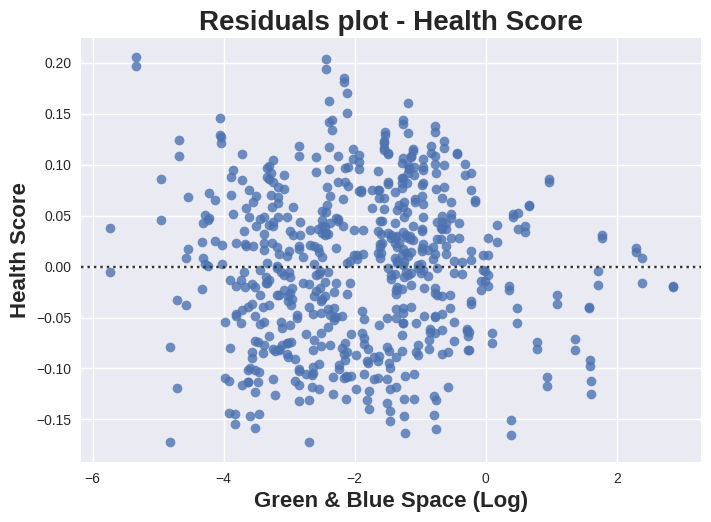

<Axes: title={'center': 'Residuals plot - Health Score'}, xlabel='Green & Blue Space (Log)', ylabel='Health Score'>

In [48]:
resi_plot(optimus_xy,'health_score', 'Residuals plot - Health Score', 'Green & Blue Space (Log)', 'Health Score')

In [49]:
# create a function to display residuals as a Histogram
def histo_ris(model, title, x_label, y_label, bins = 10, color = 'gold'):
    #Histogram of residuals
    residuals = model.resid
    sns.histplot(residuals, bins=10, color='blue', edgecolor='white')
    plt.title(title, fontweight = 'bold', fontsize = 20)
    plt.xlabel(x_label, fontweight = 'bold', fontsize = 16 )
    plt.ylabel(y_label, fontweight = 'bold', fontsize = 16)
    plt.show;
    return residuals

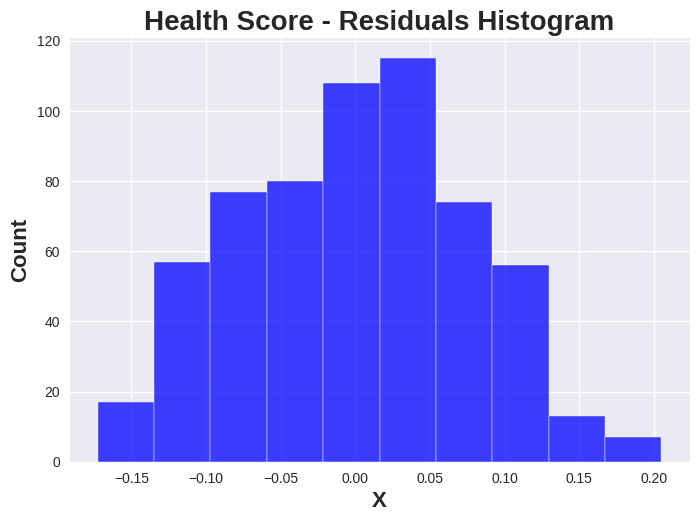

In [69]:
res_1 = histo_ris(model_1, 'Health Score - Residuals Histogram', 'X', 'Count')

In [33]:
def prop_plotter(res, title, xlabel, ylabel):
    probplot(res, plot = plt)
    plt.title(title, fontweight = 'bold', fontsize = 20)
    plt.xlabel(xlabel, fontweight = 'bold', fontsize = 16 )
    plt.ylabel(ylabel, fontweight = 'bold', fontsize = 16)
    plt.show();
    return

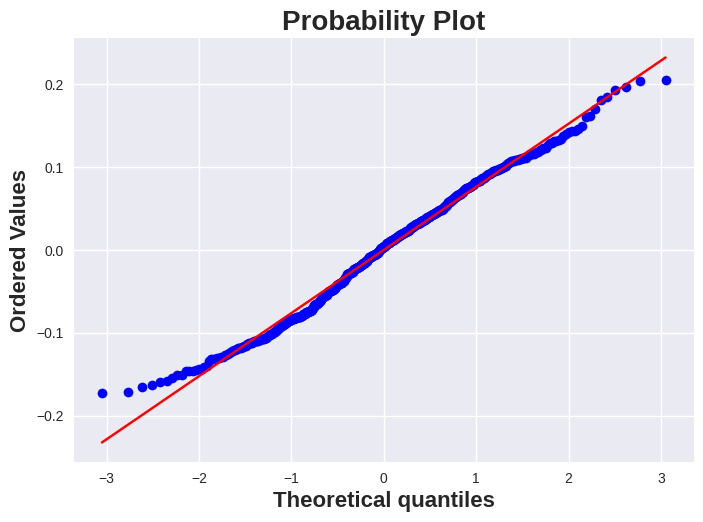

In [34]:
prop_plotter(res_1, 'Probability Plot', 'Theoretical quantiles', 'Ordered Values')

In [35]:
# Run regression model 2
model_2 = regressionator(optimus_xy, 'health_score', 'log_gs + sex_int')

                            OLS Regression Results                            
Dep. Variable:           health_score   R-squared:                       0.145
Model:                            OLS   Adj. R-squared:                  0.143
Method:                 Least Squares   F-statistic:                     51.14
Date:                Fri, 27 Mar 2026   Prob (F-statistic):           3.10e-21
Time:                        10:51:46   Log-Likelihood:                 703.38
No. Observations:                 604   AIC:                            -1401.
Df Residuals:                     601   BIC:                            -1388.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.2628      0.006    715.804      0.0

In [36]:
# Run regression model 3 with interaction effect
model_3 = regressionator(optimus_xy, 'health_score', 'log_gs + sex_int + gs_per_1000:sex_int')

                            OLS Regression Results                            
Dep. Variable:           health_score   R-squared:                       0.148
Model:                            OLS   Adj. R-squared:                  0.144
Method:                 Least Squares   F-statistic:                     34.73
Date:                Fri, 27 Mar 2026   Prob (F-statistic):           1.05e-20
Time:                        10:51:46   Log-Likelihood:                 704.27
No. Observations:                 604   AIC:                            -1401.
Df Residuals:                     600   BIC:                            -1383.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               4.2653    

In [37]:
# Run Maximal regression model 4 with all controls
model_4 = regressionator(optimus_xy, 'health_score', 'log_gs + sex_int + urban_int + imd_score')

                            OLS Regression Results                            
Dep. Variable:           health_score   R-squared:                       0.836
Model:                            OLS   Adj. R-squared:                  0.834
Method:                 Least Squares   F-statistic:                     760.7
Date:                Fri, 27 Mar 2026   Prob (F-statistic):          4.17e-233
Time:                        10:51:47   Log-Likelihood:                 1201.0
No. Observations:                 604   AIC:                            -2392.
Df Residuals:                     599   BIC:                            -2370.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.4073      0.004   1094.943      0.0

In [38]:
#create a VIF test function for checking collinearity 
def collin_check(data, vars):
    x = data[vars] #Adding all the factors to create a matrix
    x = sm.add_constant(x) #Ensuring auxiliary regressions (regressions with each predictor as the outcome) are not biased as adding a row of 1s prevents equations being forced through the origin
    vif_data = pd.DataFrame()
    vif_data["variable"] = x.columns
    vif_data["VIF"] = [variance_inflation_factor(x.values, i) #Take each column given and run the regression with the column heading as the outcome and the other variables as the predictor 
                       for i in range(x.shape[1])] #For the number of columns 
    print(vif_data)    #VIF = 1/(1-R^2), less than 5 is acceptable, close to 1 means minimal collinearity
    return vif_data

In [39]:
vif = collin_check(optimus_xy,['urban_int','log_gs','sex_int','imd_score'])

    variable  VIF
0      const 8.84
1  urban_int 1.69
2     log_gs 1.76
3    sex_int 1.00
4  imd_score 1.19


### Graph Plotting

In [40]:
# create a function to dynamically adjust the spacing of plot ticks based on the limits of the data used
def dynamic_breaks(limits, nbins = 10):
    # create a helper object to help choose evenly spaced ticks on an axis and pune the start and end for a cleaner look
    locator = mticker.MaxNLocator(nbins = nbins, prune = 'both')
    # use the locator to get tick positions between the datas upper and lower value limits
    ticks = locator.tick_values(limits[0], limits[1])
    return ticks

In [41]:
# Define function to make plots with the option to select different health variables in the data
def plot_health(data, p_title, y_title, y_var, nbins_x = 10, nbins_y = 10):
# copy the plot data to create modified sex value names
    plot_data = data.copy()
    # clean the names of copied gender values to remove anything after '_' and capitalise
    plot_data['sex_label'] = plot_data['sex'].str.split('_').str[0].str.capitalize()
    
    
    plot = (
    p9.ggplot(plot_data, p9.aes(x = 'log_gs', y = y_var, colour = 'sex_label'))
    # add both points and smooth line
    + p9.geom_point()
    + p9.geom_smooth(method = 'lm')
    
    # use the dynamic_breaks function to set breaks for the x and y axis
    + p9.scale_x_continuous(
    breaks = lambda limits: dynamic_breaks(limits, nbins = nbins_x))
    + p9.scale_y_continuous(
    breaks = lambda limits: dynamic_breaks(limits, nbins = nbins_y))
    

    # Add titles for the chart and axis
    + p9.labs(title = p_title, x = 'Log of Green Space', y = y_title, colour = 'sex')
    # Set chart theme In [44]: In [45]:
    + p9.theme_seaborn()
    # Flip the x-axis years text 45 degrees to reduce crowding and improve readability
    + p9.theme(
    plot_title = p9.element_text(size = 15, weight = 'bold', backgroundcolor='lightblue', margin={'b': 10},),
    axis_title = p9.element_text(size = 12, weight = 'bold'),
    axis_text_x = p9.element_text(rotation = 45),
    legend_background = p9.element_rect(fill = 'lightblue')
)
)
    return plot

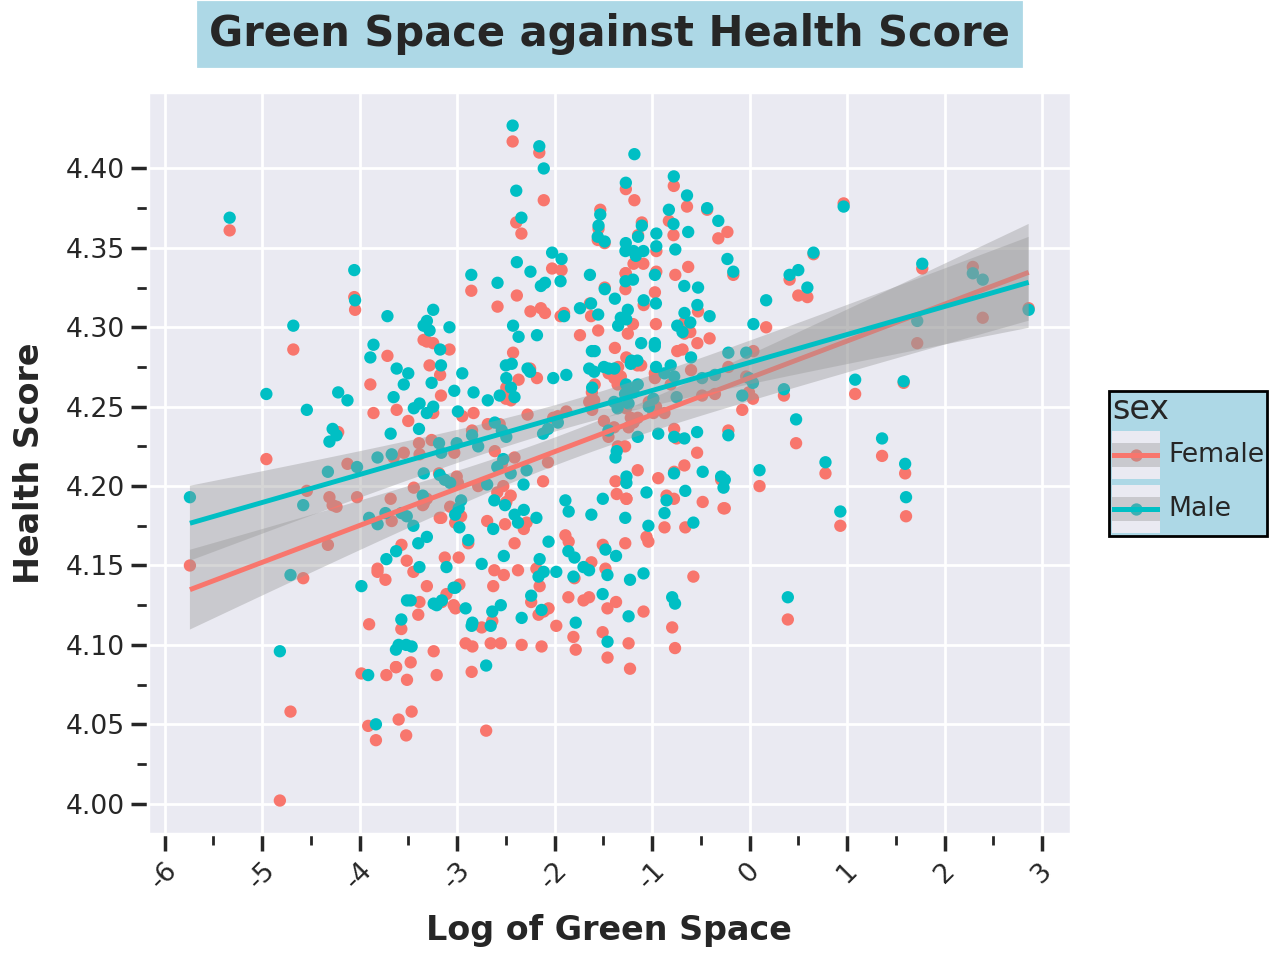

In [42]:
plot_health(optimus_xy,'Green Space against Health Score','Health Score', 'health_score', nbins_x = 10, nbins_y = 10)

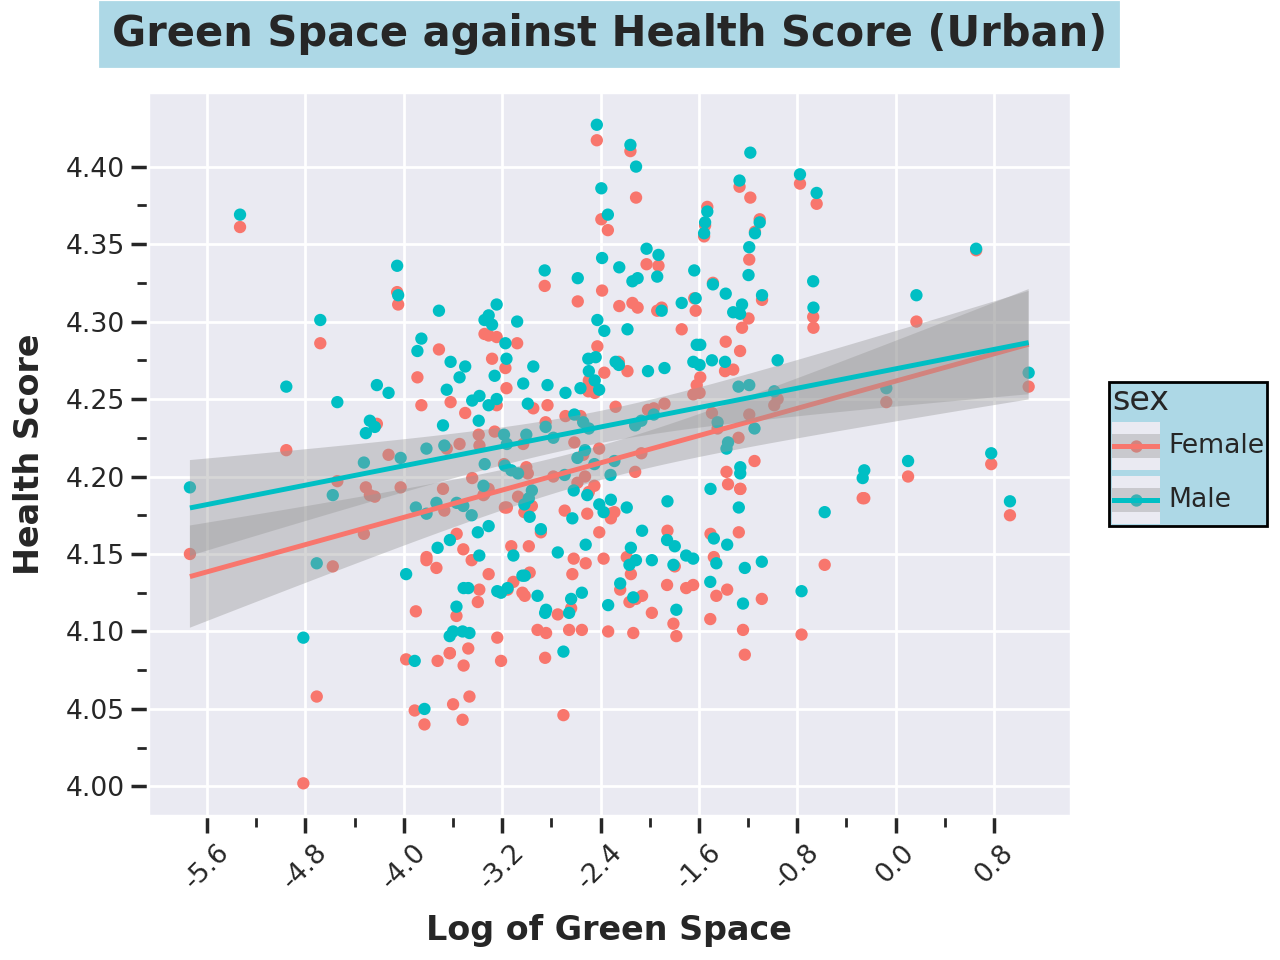

In [43]:
#For Urban Local Authorities only
plot_health(optimus_xy[optimus_xy['r_urban'] == 'Urban'],'Green Space against Health Score (Urban)','Health Score', 'health_score', nbins_x = 10, nbins_y = 10)

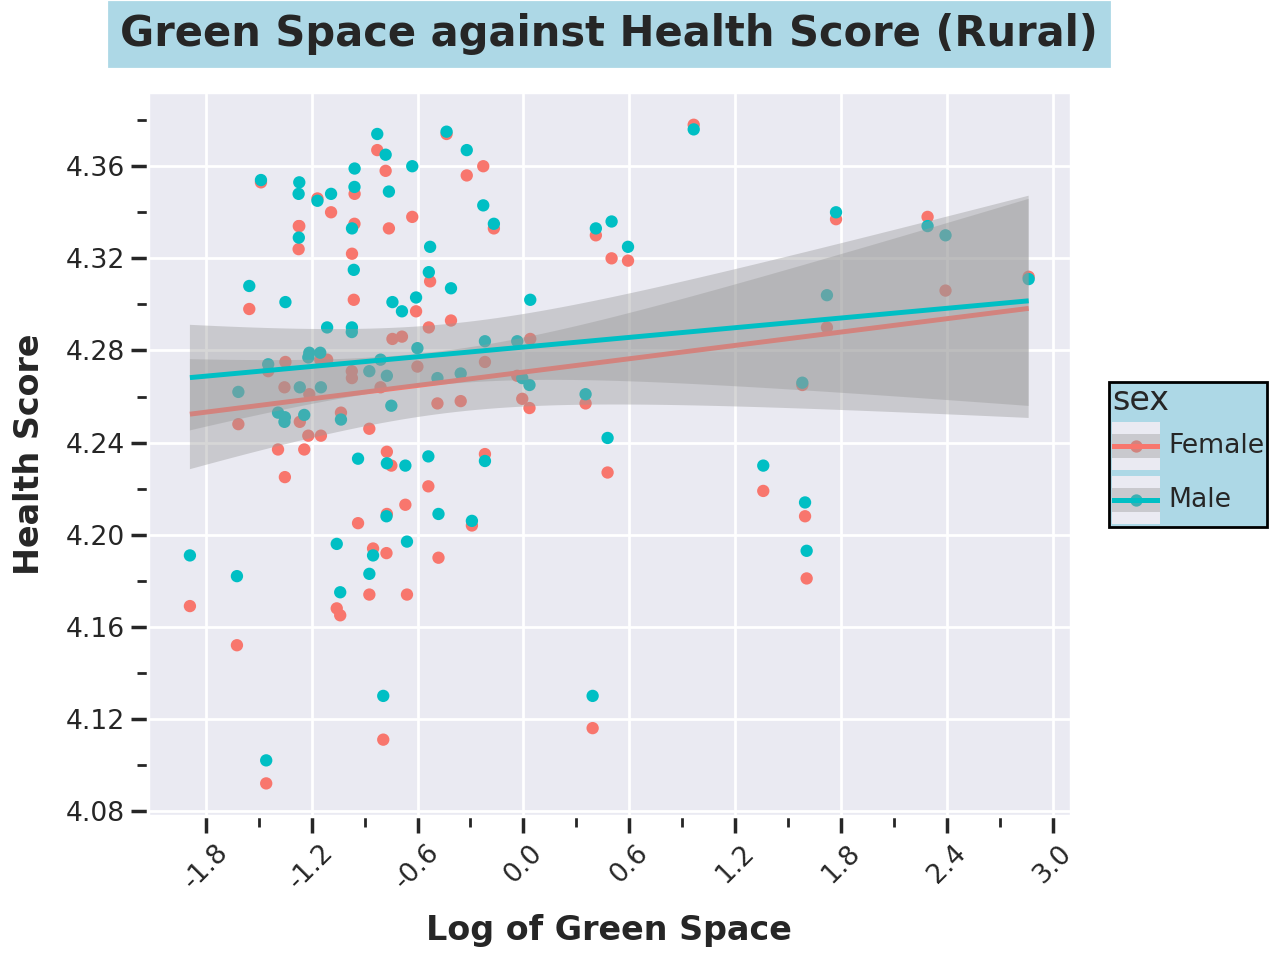

In [44]:
#For Rural Local Authorities only
plot_health(optimus_xy[optimus_xy['r_urban'] == 'Rural'],'Green Space against Health Score (Rural)','Health Score', 'health_score', nbins_x = 10, nbins_y = 10)

## Robustness Check with Healthy Life Expectancy Data

In [51]:
model_5 = regressionator(optimus_xy2, 'healthy_life_perc', 'log_gs')

                            OLS Regression Results                            
Dep. Variable:      healthy_life_perc   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                    0.6081
Date:                Fri, 27 Mar 2026   Prob (F-statistic):              0.436
Time:                        10:53:23   Log-Likelihood:                -673.04
No. Observations:                 236   AIC:                             1350.
Df Residuals:                     234   BIC:                             1357.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     73.5577      0.669    109.911      0.0

### Extra Diagnostics + using life_exp for all the rest of the regressions (not in the report)

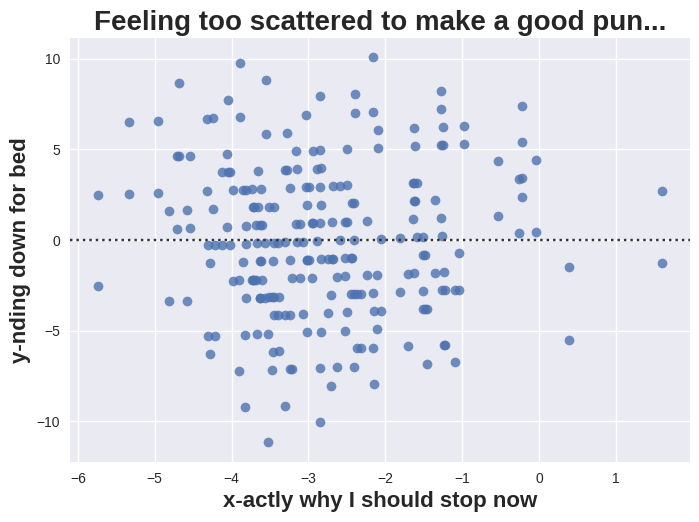

<Axes: title={'center': 'Feeling too scattered to make a good pun...'}, xlabel='x-actly why I should stop now', ylabel='y-nding down for bed'>

In [54]:
resi_plot(optimus_xy2,'healthy_life_perc', 'Feeling too scattered to make a good pun...', 'x-actly why I should stop now', 'y-nding down for bed' )

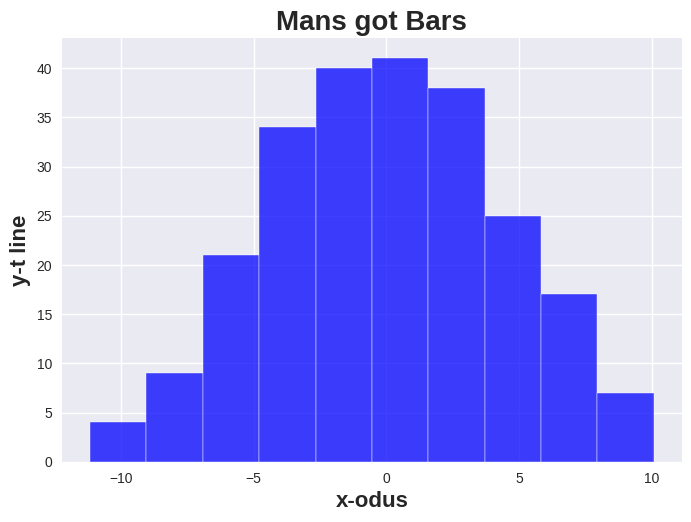

In [55]:
res_2 = histo_ris(model_5, 'Mans got Bars', 'x-odus', 'y-t line')

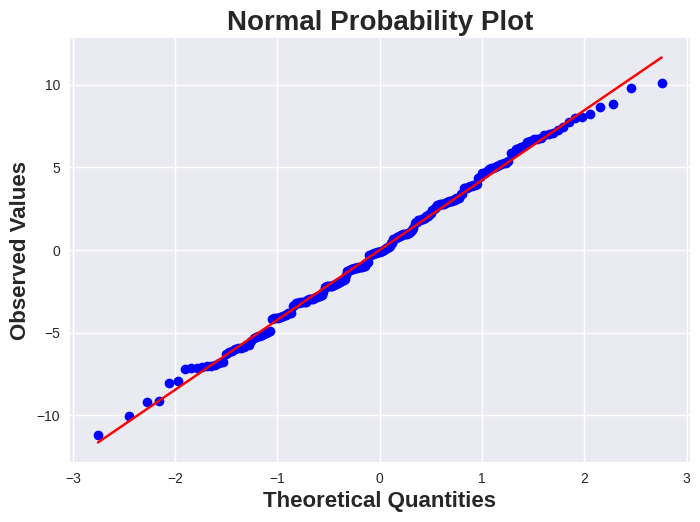

In [73]:
prop_plotter(res_2, 'Normal Probability Plot', 'Theoretical Quantities', 'Observed Values')

In [59]:
model_6 = regressionator(optimus_xy2, 'healthy_life_perc', 'log_gs + sex_int')

                            OLS Regression Results                            
Dep. Variable:      healthy_life_perc   R-squared:                       0.179
Model:                            OLS   Adj. R-squared:                  0.172
Method:                 Least Squares   F-statistic:                     25.41
Date:                Fri, 27 Mar 2026   Prob (F-statistic):           1.04e-10
Time:                        10:54:03   Log-Likelihood:                -650.06
No. Observations:                 236   AIC:                             1306.
Df Residuals:                     233   BIC:                             1317.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     71.7950      0.657    109.197      0.0

In [60]:
model_7 = regressionator(optimus_xy2, 'healthy_life_perc', 'log_gs + sex_int + gs_per_1000:sex_int')

                            OLS Regression Results                            
Dep. Variable:      healthy_life_perc   R-squared:                       0.180
Model:                            OLS   Adj. R-squared:                  0.169
Method:                 Least Squares   F-statistic:                     16.97
Date:                Fri, 27 Mar 2026   Prob (F-statistic):           5.31e-10
Time:                        10:54:07   Log-Likelihood:                -649.93
No. Observations:                 236   AIC:                             1308.
Df Residuals:                     232   BIC:                             1322.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              71.6588    

In [61]:
model_8 = regressionator(optimus_xy2, 'healthy_life_perc', 'log_gs + sex_int + urban_int + imd_score')

                            OLS Regression Results                            
Dep. Variable:      healthy_life_perc   R-squared:                       0.615
Model:                            OLS   Adj. R-squared:                  0.608
Method:                 Least Squares   F-statistic:                     92.19
Date:                Fri, 27 Mar 2026   Prob (F-statistic):           9.93e-47
Time:                        10:54:11   Log-Likelihood:                -560.75
No. Observations:                 236   AIC:                             1132.
Df Residuals:                     231   BIC:                             1149.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     78.8816      0.699    112.875      0.0

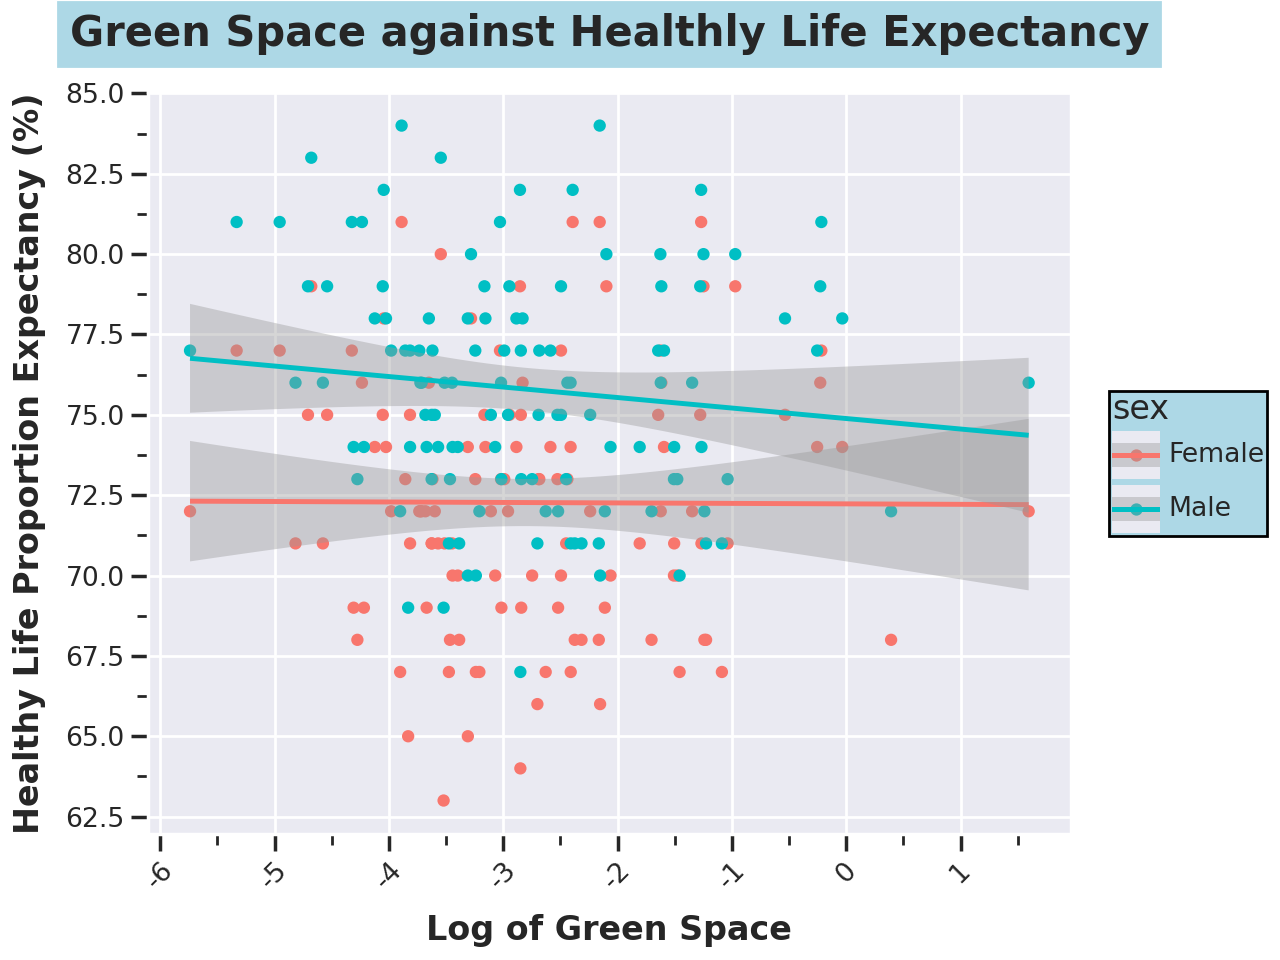

In [65]:
plot_health(optimus_xy2,'Green Space against Healthly Life Expectancy','Healthy Life Proportion Expectancy (%)','healthy_life_perc', nbins_x = 10, nbins_y = 10)

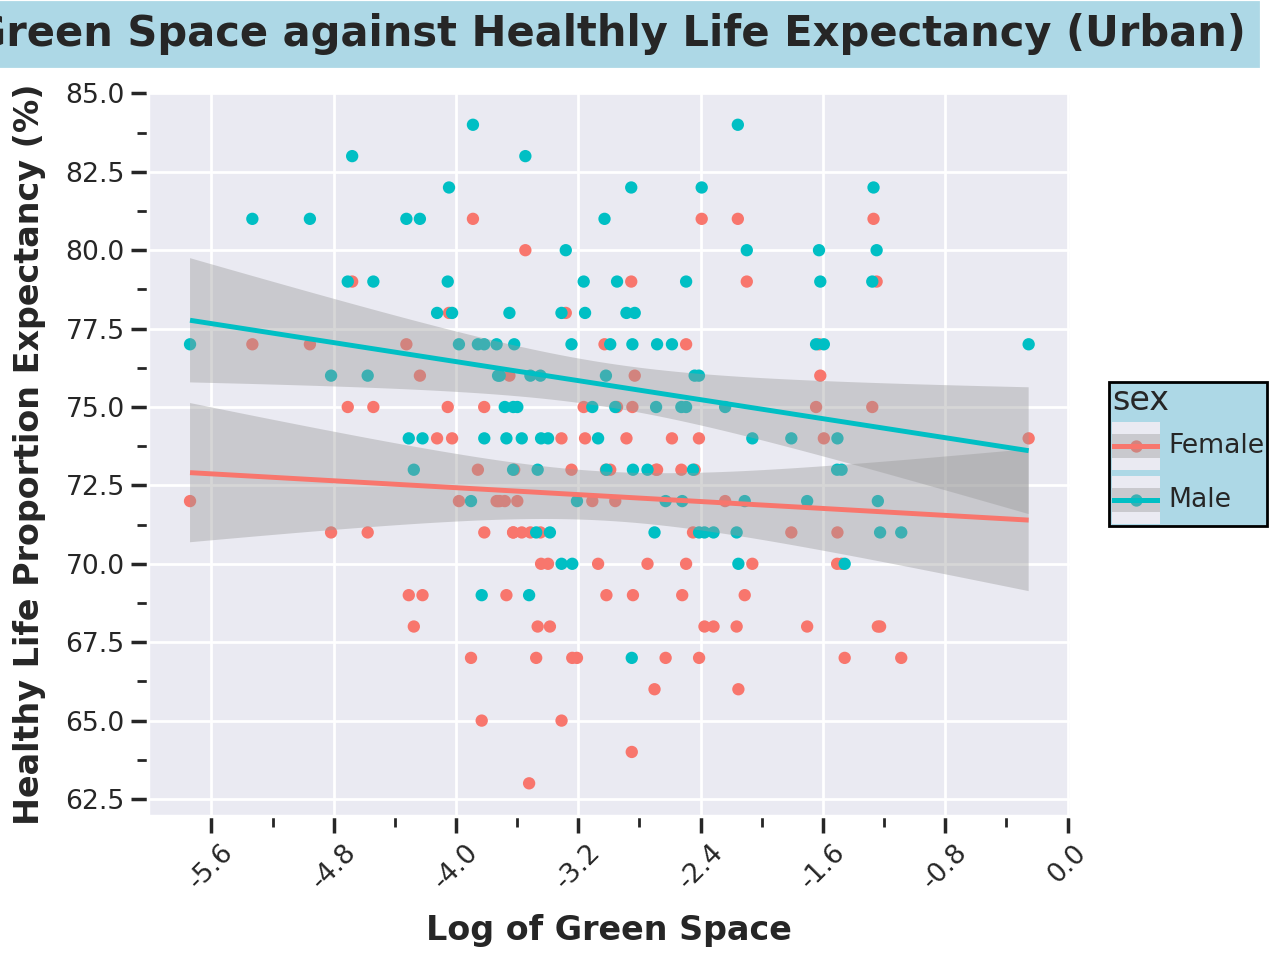

In [66]:
#For Urban Local Authorities only
plot_health(optimus_xy2[optimus_xy2['r_urban'] == 'Urban'],'Green Space against Healthly Life Expectancy (Urban)','Healthy Life Proportion Expectancy (%)', 'healthy_life_perc', nbins_x = 10, nbins_y = 10)

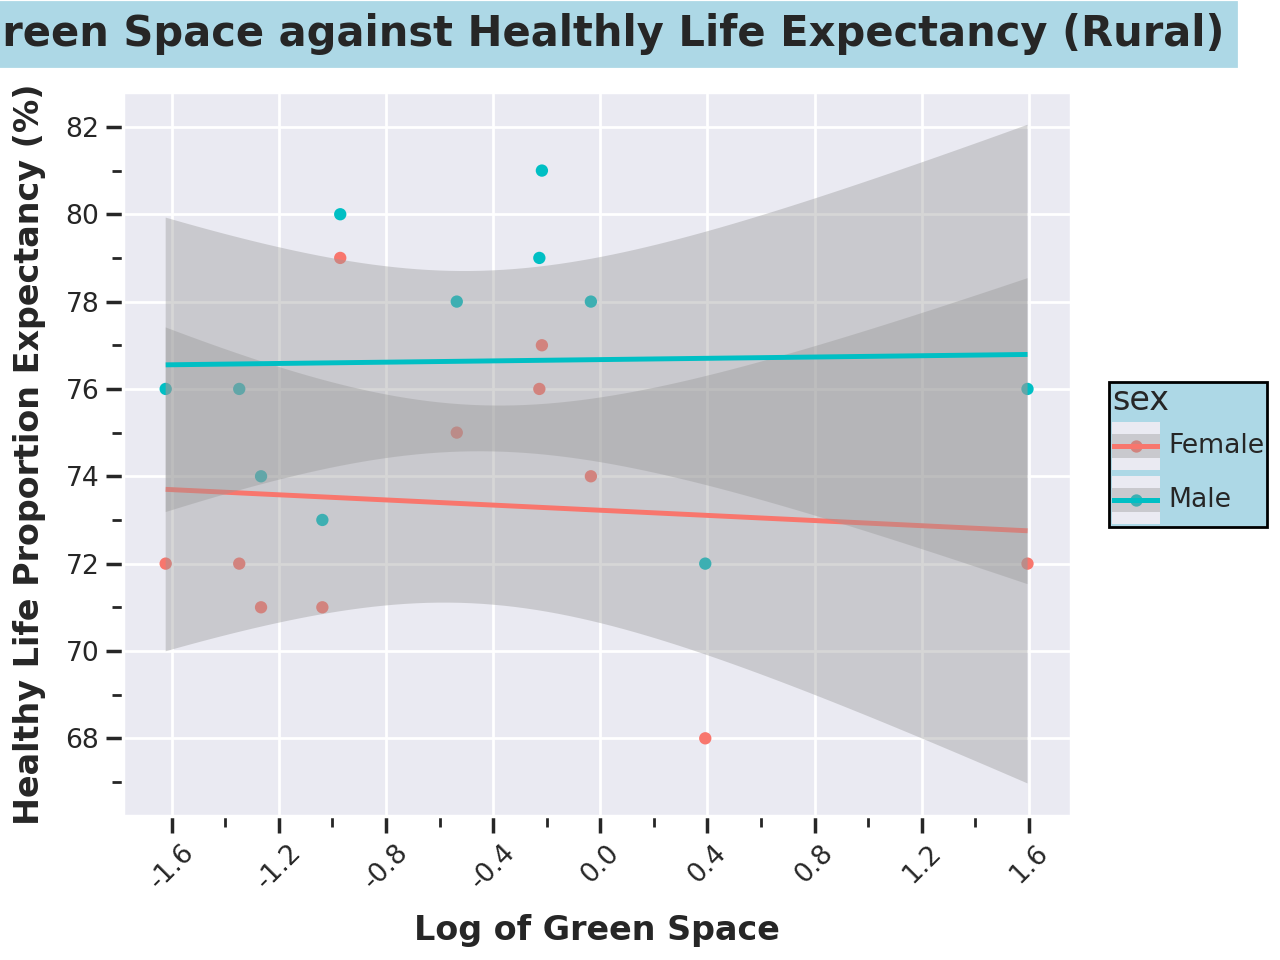

In [67]:
#For Rural Local Authorities only
plot_health(optimus_xy2[optimus_xy2['r_urban'] == 'Rural'],'Green Space against Healthly Life Expectancy (Rural)','Healthy Life Proportion Expectancy (%)', 'healthy_life_perc', nbins_x = 10, nbins_y = 10)